In [1]:
#Practive project 
# To understand the whole process of ml model building 
# The problem is simple classification problem 


#  steps
#0. preprocessing + EDA + Feature selection
#1. Extract input and output columns 
#2. Scale the vallue
#3. Train test split 
#4. Train the model 
#5. Evaluate the model/model selction 
#6. Deploy the model

In [2]:
import numpy as np 
import pandas as pd 

In [3]:
# data reading

In [4]:
df = pd.read_csv('trading_classification.csv')
df.head()

,market_sentiment,price_change_pct,price_direction,unnamed
0,3.92,0.15,0,1
1,7.46,-1.35,1,1
2,3.19,-3.40,0,1
3,1.19,-0.68,0,1
4,3.47,4.51,1,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   market_sentiment  450 non-null    float64
 1   price_change_pct  450 non-null    float64
 2   price_direction   450 non-null    int64  
 3   unnamed           450 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 14.2 KB


## data preprocessing  

In [6]:
# here removing unnamed column , no other missing valuse ( checked by df.into() )

In [7]:
df = df.drop(columns=['unnamed'])  # removing column unnamed as its unnecesaary
df 

,market_sentiment,price_change_pct,price_direction
0,3.92,0.15,0
1,7.46,-1.35,1
2,3.19,-3.40,0
3,1.19,-0.68,0
4,3.47,4.51,1
...,...,...,...
445,8.80,1.38,1
446,5.17,1.09,0
447,8.54,2.36,1
448,7.76,4.40,1


## EDA  (exploratory dat taanalysis ) ploting graph for basic view

In [8]:
import matplotlib.pyplot as plt

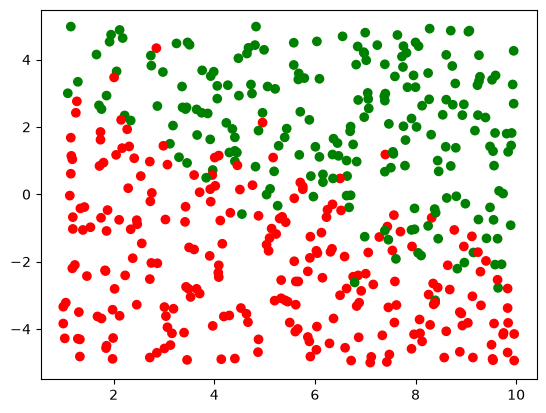

In [9]:
# Map 0 to 'red' and 1 to 'green'
colors = ['green' if x == 1 else 'red' for x in df["price_direction"]]

plt.scatter(df["market_sentiment"], df["price_change_pct"], c=colors)  
# purple are 0 = down and yellow are 1 = up

# selcting logistic regression as single line can separate the outputs

## Feature selection

In [10]:
# no feature selection done as only 2 independetn variable is used

## Extracting input and outputs cols

In [11]:
# independetn variable = market_sentiment, price_change_pct  and dependent variable = price_direction
x =df.iloc[:,0:2]
y = df.iloc[:,-1]
x  

,market_sentiment,price_change_pct
0,3.92,0.15
1,7.46,-1.35
2,3.19,-3.40
3,1.19,-0.68
4,3.47,4.51
...,...,...
445,8.80,1.38
446,5.17,1.09
447,8.54,2.36
448,7.76,4.40


In [12]:
y    #(price_direction)

0      0
1      1
2      0
3      0
4      1
      ..
445    1
446    0
447    1
448    1
449    0
Name: price_direction, Length: 450, dtype: int64

## Train test split 

In [13]:
from sklearn.model_selection import train_test_split 

x_train,x_test,y_train, y_test = train_test_split(x,y,test_size=0.1)   # mentioning test size is 10% of whole seet 

In [14]:
x_train  # x variables for training set  (market_sentiment, price_change_pct)

,market_sentiment,price_change_pct
378,4.41,-4.88
271,1.33,-4.31
139,8.28,4.92
76,5.62,-3.28
232,5.66,-4.00
...,...,...
392,7.10,-5.00
398,1.33,-4.82
314,5.26,-0.34
25,4.09,1.15


In [15]:
y_train  # y variable for training set (price_direction)

378    0
271    0
139    1
76     0
232    0
      ..
392    0
398    0
314    1
25     0
57     1
Name: price_direction, Length: 405, dtype: int64

In [16]:
x_test  # x variable for test set   (market_sentiment, price_change_pct)

,market_sentiment,price_change_pct
112,8.96,-1.55
144,8.39,-3.15
63,9.28,3.49
325,6.31,-1.71
23,6.23,-0.68
388,9.07,4.86
22,5.58,3.84
356,3.53,-3.05
102,9.59,3.53
218,4.76,0.27


In [17]:
y_test  # y variable for test set (price_direction)

112    0
144    1
63     1
325    0
23     0
388    1
22     1
356    0
102    1
218    0
133    0
96     0
417    1
108    0
106    1
256    0
197    0
16     1
38     1
338    0
352    0
395    0
394    1
142    1
205    0
258    1
227    1
370    0
189    0
290    0
292    1
410    0
244    1
285    1
229    1
182    1
253    0
383    0
320    1
17     0
384    0
1      1
209    1
431    1
275    0
Name: price_direction, dtype: int64

## scaling the values

In [18]:
 from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()   # objecting the class

In [20]:
x_train

,market_sentiment,price_change_pct
378,4.41,-4.88
271,1.33,-4.31
139,8.28,4.92
76,5.62,-3.28
232,5.66,-4.00
...,...,...
392,7.10,-5.00
398,1.33,-4.82
314,5.26,-0.34
25,4.09,1.15


In [21]:
x_test

,market_sentiment,price_change_pct
112,8.96,-1.55
144,8.39,-3.15
63,9.28,3.49
325,6.31,-1.71
23,6.23,-0.68
388,9.07,4.86
22,5.58,3.84
356,3.53,-3.05
102,9.59,3.53
218,4.76,0.27


## training the model

In [22]:
from sklearn.linear_model import LogisticRegression  # this contains class of logistic regreation

In [23]:
clf = LogisticRegression() # creating the object 

In [24]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [25]:
#Model has succefully trained

# classes_         → Shows the different output classes the model can predict: 0 = DOWN, 1 = UP
# coef_            → Shows the learned weight/importance of each input feature
# intercept_       → Shows the learned bias/starting point of the model
# n_features_in_   → Shows the number of input features used to train the model (here: 2)
# classes_ [0, 1]  → The model learned to distinguish between two classes: DOWN and UP

## Model Evaluation

In [26]:
y_pred = clf.predict(x_test)   #predicting the y using stored x_test set and storing in y_pred

In [27]:
y_test  #actual result or answer of trainig set

112    0
144    1
63     1
325    0
23     0
388    1
22     1
356    0
102    1
218    0
133    0
96     0
417    1
108    0
106    1
256    0
197    0
16     1
38     1
338    0
352    0
395    0
394    1
142    1
205    0
258    1
227    1
370    0
189    0
290    0
292    1
410    0
244    1
285    1
229    1
182    1
253    0
383    0
320    1
17     0
384    0
1      1
209    1
431    1
275    0
Name: price_direction, dtype: int64

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test,y_pred)  # measuring the accuracy of model

0.8666666666666667

In [30]:
# plot decision boundery (visualise the pattern recognized by model)
# using lib mlxtend  

In [31]:
!pip install mlxtend  #installing lib

In [32]:
from mlxtend.plotting import plot_decision_regions

/home/saaho/anaconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

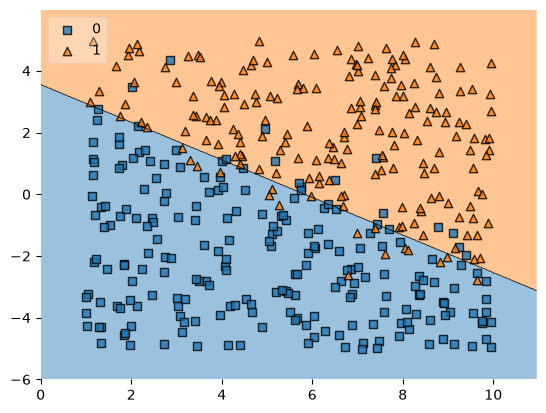

In [33]:
plot_decision_regions(x_train.values, y_train.values, clf=clf, legend=2) 
# converting x_train and y_train to numpy array by puseing x_train.values

## Deploying


In [34]:
import pickle 
#pickle convert python object to file , we can use that file in  other envs

In [1]:
#run this command to create model file (model.pkl)
"""pickle.dump(clf,open('model.pkl','wb'))  """

"pickle.dump(clf,open('model.pkl','wb'))  "

In [36]:
# model.pkl is ready to deploy (the front end integrated model)

In [37]:
# deploy can be done in 
"""
AWS
Heroku
gcp
"""

'\nAWS\nHeroku\ngcp\n'